# Exp. 1 Baseline: Bicubic Upsampling

A super-resolution style baseline for Exp. 1 (political campaigning).
The regional outcomes are treated as a coarse $10 \times 10$ image and upsampled
to the $40 \times 40$ subregion grid with bicubic interpolation. The interpolated map is then
used as a pseudo high-resolution training target for the same network Clam uses
(exactly like the uniform baseline, but with a smooth target instead of a constant one).

**Expectation.** Bicubic upsampling only exploits *where* a subregion is, never its context $c$.
Since the heterogeneity in Exp. 1 is context-driven and spatially unstructured, the baseline
should not recover the local causal effects (LOCATE).

## Setup and data (identical to Exp. 1)

In [1]:
# Figures are only shown inside Colab. In Jupyter they render inline, and in
# a plain script no window is opened and figures are closed right away.
try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

try:
    IN_NOTEBOOK = get_ipython() is not None
except NameError:
    IN_NOTEBOOK = False

if not IN_COLAB and not IN_NOTEBOOK:
    import matplotlib

    matplotlib.use("Agg")  # never open a window
    import matplotlib.pyplot as plt

    plt.show = lambda *a, **k: plt.close("all")  # disarm any stray plt.show()


def show_figure():
    """Replaces plt.show(): display interactively, close in a script."""
    if IN_COLAB:
        plt.show()
    elif not IN_NOTEBOOK:
        plt.close("all")

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Parameters, identical to Exp. 1 (political campaigning)
SEED = 42
ROW = 100          # number of regions, arranged on a 10 x 10 grid
COL = 16           # subregions per region, arranged on a 4 x 4 grid
N_SWAPS = 100      # random pair swaps in the context matrix
NOISE_STD = 0.1    # observation noise on the subregional outcomes
N_EPOCHS = 4000
LR = 1e-3
WEIGHT_DECAY = 1e-3
HIDDEN_DIM = 32
DROPOUT = 0.05


def set_all_seeds(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)


In [2]:
def true_f(t, c):
    """Ground-truth mechanism: outcome is 1 if untreated,
    and a piecewise-linear function of the context if treated."""
    anchor_x = np.array([-100, -2, 0, 1, 100], dtype=float)
    anchor_y = np.array([2, 2, 1, 0, 0], dtype=float)
    return np.where(t == 0, 1.0, np.interp(c, anchor_x, anchor_y))


def create_context_matrix():
    """Row-centered Gaussian context with random swaps,
    so the regional mean context is uninformative by construction."""
    C = np.random.normal(size=(ROW, COL))
    C = C - C.mean(axis=1, keepdims=True)
    for _ in range(N_SWAPS):
        r1, c1 = np.random.randint(ROW), np.random.randint(COL)
        r2, c2 = np.random.randint(ROW), np.random.randint(COL)
        C[r1, c1], C[r2, c2] = C[r2, c2], C[r1, c1]
    return C


def create_treatment_matrix():
    """Half of the regions are treated; treatment covers all subregions of a region."""
    flags = np.array([1] * (ROW // 2) + [0] * (ROW // 2))
    np.random.shuffle(flags)
    return np.repeat(flags[:, None], COL, axis=1).astype(float)


set_all_seeds(SEED)
T = create_treatment_matrix()
C = create_context_matrix()
Y = true_f(T, C) + np.random.normal(scale=NOISE_STD, size=(ROW, COL))

Y_agg = Y.mean(axis=1)                                # observed regional outcomes (the only supervision)
E_true = true_f(T, C) - true_f(np.zeros_like(T), C)   # ground-truth LOCATE, used only for evaluation


## Model and training (identical to Exp. 1)

In [3]:
class SmallMLP(nn.Module):
    """f_theta(t, c): two inputs, one scalar output. Same architecture as in Exp. 1."""

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, HIDDEN_DIM), nn.ReLU(), nn.Dropout(DROPOUT),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM), nn.ReLU(), nn.Dropout(DROPOUT),
            nn.Linear(HIDDEN_DIM, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def features(T_mat, C_mat):
    return torch.tensor(np.stack([T_mat, C_mat], axis=-1), dtype=torch.float32).reshape(-1, 2)


def locate_matrix(model, T_mat, C_mat):
    """LOCATE estimate: f(t, c) - f(0, c) for every subregion."""
    model.eval()
    with torch.no_grad():
        pred = model(features(T_mat, C_mat)).reshape(ROW, COL)
        pred0 = model(features(np.zeros_like(T_mat), C_mat)).reshape(ROW, COL)
    return (pred - pred0).numpy()


def train(target, aggregate_loss):
    """Train f_theta and record the LOCATE MAE over training.

    aggregate_loss=True : Clam. `target` is the vector of regional outcomes;
                          the loss compares the regional mean of the predictions to it.
    aggregate_loss=False: baseline. `target` is a ROW x COL matrix of pseudo
                          subregional outcomes; the loss is element-wise.
    """
    set_all_seeds(SEED)
    model = SmallMLP()
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    X = features(T, C)
    X0 = features(np.zeros_like(T), C)
    target_t = torch.tensor(target, dtype=torch.float32)
    E_true_t = torch.tensor(E_true, dtype=torch.float32)

    mae_history = []
    loss_history = []
    for epoch in range(N_EPOCHS):
        model.train()
        pred = model(X).reshape(ROW, COL)
        if aggregate_loss:
            loss = torch.mean((pred.mean(dim=1) - target_t) ** 2)
        else:
            loss = torch.mean((pred - target_t) ** 2)
        opt.zero_grad()
        loss.backward()
        opt.step()
        loss_history.append(loss.item())

        model.eval()
        with torch.no_grad():
            E_pred = (model(X) - model(X0)).reshape(ROW, COL)
            mae_history.append(torch.mean(torch.abs(E_pred - E_true_t)).item())

    return model, mae_history, loss_history


## Bicubic disaggregation of the regional outcomes

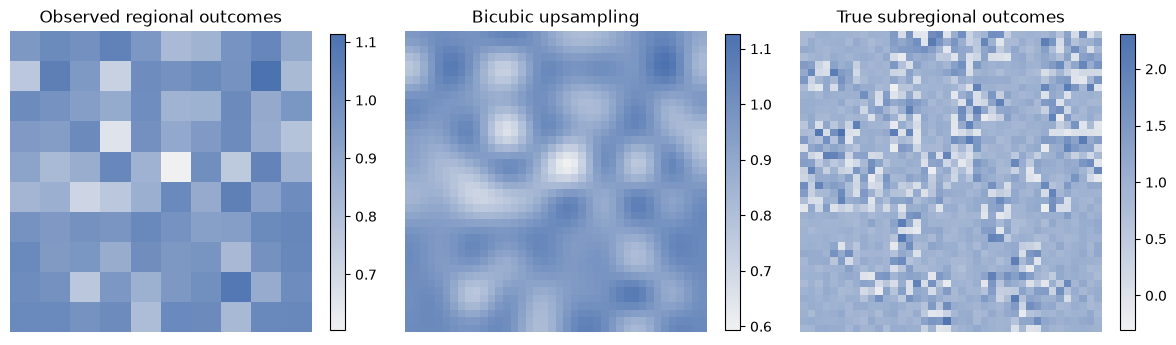

In [4]:
def to_grid(M):
    """Rearrange a (ROW, COL) region-by-subregion matrix into its (40, 40) spatial map."""
    R, S = int(np.sqrt(ROW)), int(np.sqrt(COL))
    grid = np.zeros((R * S, R * S))
    for i in range(ROW):
        for j in range(COL):
            grid[(i // R) * S + (j // S), (i % R) * S + (j % S)] = M[i, j]
    return grid


def from_grid(grid):
    """Inverse of to_grid: (40, 40) spatial map back to a (ROW, COL) matrix."""
    R, S = int(np.sqrt(ROW)), int(np.sqrt(COL))
    M = np.zeros((ROW, COL))
    for i in range(ROW):
        for j in range(COL):
            M[i, j] = grid[(i // R) * S + (j // S), (i % R) * S + (j % S)]
    return M


import seaborn as sns
from scipy.ndimage import zoom

colors = sns.color_palette("deep")
blue_cmap = sns.light_palette(colors[0], as_cmap=True)  # Blue, Outcome

Y_coarse = Y_agg.reshape(10, 10)     # one pixel per region
Y_up = zoom(Y_coarse, 4, order=3)    # bicubic upsampling to the 40 x 40 subregion grid
Y_bicubic = from_grid(Y_up)          # back to (ROW, COL) indexing, used as training target

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img, title in zip(axes,
                          [Y_coarse, Y_up, to_grid(Y)],
                          ["Observed regional outcomes", "Bicubic upsampling", "True subregional outcomes"]):
    im = ax.imshow(img, cmap=blue_cmap)
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig("exp1_bicubic_disaggregation.jpg", dpi=200, bbox_inches="tight")
plt.savefig("exp1_bicubic_disaggregation.pdf", bbox_inches="tight")
show_figure()


## Train Clam and the two baselines

In [5]:
Y_uniform = np.repeat(Y_agg[:, None], COL, axis=1)  # uniform disaggregation target

model_clam, mae_clam, loss_clam = train(Y_agg, aggregate_loss=True)
model_uniform, mae_uniform, loss_uniform = train(Y_uniform, aggregate_loss=False)
model_bicubic, mae_bicubic, loss_bicubic = train(Y_bicubic, aggregate_loss=False)

print(f"final LOCATE MAE | Clam: {mae_clam[-1]:.4f} | "
      f"uniform: {mae_uniform[-1]:.4f} | bicubic: {mae_bicubic[-1]:.4f}")


final LOCATE MAE | Clam: 0.0140 | uniform: 0.2503 | bicubic: 0.2510


## Results

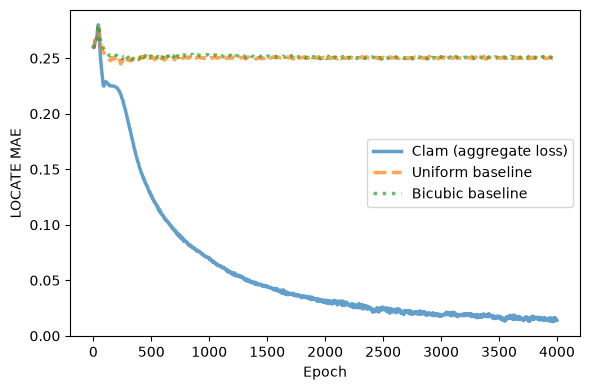

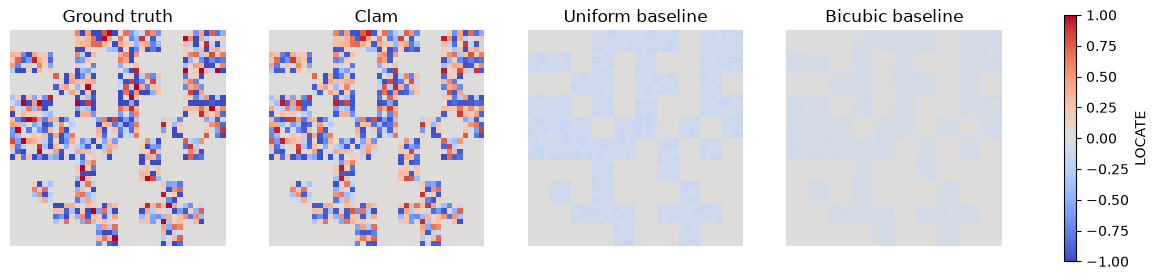

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(mae_clam, label="Clam (aggregate loss)", lw=2.5, alpha=0.7, linestyle="-")
ax.plot(mae_uniform, label="Uniform baseline", lw=2.5, alpha=0.7, linestyle="--")
ax.plot(mae_bicubic, label="Bicubic baseline", lw=2.5, alpha=0.7, linestyle=":")
ax.set_xlabel("Epoch")
ax.set_ylabel("LOCATE MAE")
ax.legend()
plt.tight_layout()
plt.savefig("exp1_bicubic_locate_mae.jpg", dpi=200, bbox_inches="tight")
plt.savefig("exp1_bicubic_locate_mae.pdf", bbox_inches="tight")
show_figure()

estimates = [E_true,
             locate_matrix(model_clam, T, C),
             locate_matrix(model_uniform, T, C),
             locate_matrix(model_bicubic, T, C)]
titles = ["Ground truth", "Clam", "Uniform baseline", "Bicubic baseline"]

vmin = min(E.min() for E in estimates)
vmax = max(E.max() for E in estimates)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, E, title in zip(axes, estimates, titles):
    im = ax.imshow(to_grid(E), cmap="coolwarm", vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis("off")
fig.colorbar(im, ax=axes, shrink=0.8, label="LOCATE")
plt.savefig("exp1_bicubic_locate_maps.jpg", dpi=200, bbox_inches="tight")
plt.savefig("exp1_bicubic_locate_maps.pdf", bbox_inches="tight")
show_figure()


## Goodman reference (ecological regression)

Least squares at the regional level, with the treatment coefficient copied to every treated
subregion. There is no training loop, so this baseline enters the plot below as a constant.


In [7]:
# Goodman-style ecological regression: regress the regional outcome on the regional
# treatment and the regional mean context, then hand the coefficient down unchanged.
T_reg = T.mean(axis=1)
C_reg = C.mean(axis=1)

X_reg = np.column_stack([np.ones(ROW), T_reg, C_reg])
beta, *_ = np.linalg.lstsq(X_reg, Y_agg, rcond=None)
beta_T = beta[1]

E_goodman = beta_T * T
mae_goodman = np.abs(E_goodman - E_true).mean()

print(f"ecological effect estimate beta_T = {beta_T:.4f}")
print(f"LOCATE MAE (Goodman, constant)    = {mae_goodman:.4f}")


ecological effect estimate beta_T = -0.1165
LOCATE MAE (Goodman, constant)    = 0.2580


## Combined loss plot

Same style as the Exp. 1 figure in the main notebook: LOCATE MAE on the left axis (dashed),
training loss on the right axis (solid), with opacity distinguishing the three trained runs.
Goodman has no training curve and is drawn as a gray horizontal line.


In [8]:
import pandas as pd

SMOOTHING_WINDOW = 45   # as in the Exp. 1 notebook
SHOW_LEGEND = True

colors = sns.color_palette("deep")
blue_color = colors[0]   # training loss, everywhere
red_color = colors[3]    # LOCATE MAE, everywhere


def smooth_curve(values, window=SMOOTHING_WINDOW):
    """Smooth a 1D curve using a centered moving average."""
    values = np.asarray(values, dtype=float)

    if window <= 1:
        return values

    return pd.Series(values).rolling(
        window=window,
        center=True,
        min_periods=1,
    ).mean().values


def save_combined_loss_plot(filename, loglog=False):
    """One panel per method. Red is always the LOCATE MAE, blue always the training loss;
    the line style identifies the method. Goodman has no training curve and appears in
    every panel as a thin horizontal LOCATE reference."""
    runs = [
        ("Clam (aggregate loss)", mae_clam, loss_clam, "-"),
        ("Uniform baseline", mae_uniform, loss_uniform, "--"),
        ("Bicubic baseline", mae_bicubic, loss_bicubic, ":"),
    ]
    epochs = np.arange(1, len(mae_clam) + 1)

    mae_curves = [smooth_curve(mae) for _, mae, _, _ in runs]
    loss_curves = [smooth_curve(loss) for _, _, loss, _ in runs]

    # shared ranges, so the three panels can be compared directly
    mae_lo = min(min(c.min() for c in mae_curves), mae_goodman)
    mae_hi = max(max(c.max() for c in mae_curves), mae_goodman)
    loss_lo = min(c.min() for c in loss_curves)
    loss_hi = max(c.max() for c in loss_curves)
    pad = (lambda lo, hi: (lo * 0.8, hi * 1.25)) if loglog else (lambda lo, hi: (lo - 0.05 * (hi - lo), hi + 0.05 * (hi - lo)))

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True)

    for k, ((label, _, _, style), ax_left) in enumerate(zip(runs, axes)):
        ax_left.set_title(label, fontsize=18)
        ax_left.set_xlabel("Epoch", fontsize=18)

        if loglog:
            ax_left.set_xscale("log")
            ax_left.set_yscale("log")

        ax_left.plot(
            epochs, mae_curves[k],
            color=red_color, linestyle=style, linewidth=4, alpha=0.95,
            label="LOCATE MAE", zorder=3,
        )
        ax_left.axhline(
            mae_goodman,
            color=red_color, linestyle=(0, (1, 1.6)), linewidth=2, alpha=0.7,
            label="LOCATE MAE (Goodman)", zorder=2,
        )
        ax_left.set_ylim(*pad(mae_lo, mae_hi))
        ax_left.tick_params(axis="both", which="both", length=0, labelsize=16, colors=red_color)
        ax_left.spines["top"].set_visible(False)

        ax_right = ax_left.twinx()
        if loglog:
            ax_right.set_yscale("log")

        ax_right.plot(
            epochs, loss_curves[k],
            color=blue_color, linestyle=style, linewidth=3, alpha=0.95,
            label="Training loss", zorder=3,
        )
        ax_right.set_ylim(*pad(loss_lo, loss_hi))
        ax_right.tick_params(axis="y", which="both", length=0, labelsize=16, colors=blue_color)
        ax_right.spines["top"].set_visible(False)

        # axis labels and tick labels only on the outer edges
        if k == 0:
            ax_left.set_ylabel("LOCATE MAE", fontsize=18, color=red_color)
        else:
            ax_left.tick_params(labelleft=False)

        if k == len(runs) - 1:
            ax_right.set_ylabel("Training Loss", fontsize=18, color=blue_color)
        else:
            ax_right.tick_params(labelright=False)

        if SHOW_LEGEND and k == 0:
            handles = ax_left.get_legend_handles_labels()[0] + ax_right.get_legend_handles_labels()[0]
            labels = ax_left.get_legend_handles_labels()[1] + ax_right.get_legend_handles_labels()[1]
            ax_left.legend(handles, labels, loc="lower left", fontsize=13, frameon=False)

    plt.tight_layout()

    fig.savefig(f"{filename}.jpg", dpi=300, bbox_inches="tight")
    fig.savefig(f"{filename}.pdf", bbox_inches="tight")

    show_figure()
    plt.close(fig)


save_combined_loss_plot("exp1_baselines_combined_linear", loglog=False)
save_combined_loss_plot("exp1_baselines_combined_loglog", loglog=True)
